The paper "LeJEPA: Provable and Scalable Self-Supervised Learning Without the Heuristics"[@balestriero2025] proposed an interesting method of regularizing latent spaces that I thought I'd explore.

This is a regularization technique to make latent embeddings have isotropic Gaussian distribution - each dimension is encouraged to be uncorrelated and independent, and gaussian distributed. They argue that gaussian latent embeddings are optimal because they are unbiased and lower variance for downstream tasks.

They make latent embeddings have Gaussian distribution using one-dimensional tests of normality in random directions via characteristic functions.

# One-Dimension
## ECDF Tests

First the paper motivates determining how Gaussian a distribution is with its empirical (i.e. observed) cumulative distribution function (ecdf). Lets look at this in one-dimension.

First we generate two "one sample" univariate datasets - one uniform and one standard gaussian. In this case the target distribution is the standard gaussian. Then we just compare the ecdfs with the theoretical gaussian cdf.

In [3]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import torch

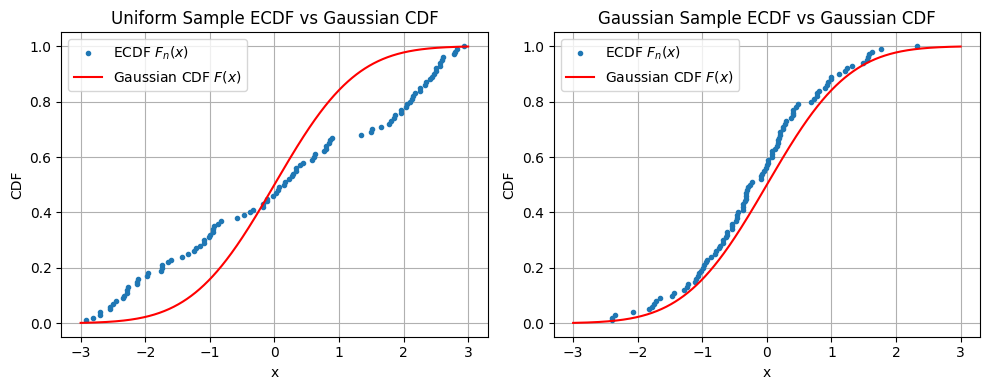

In [4]:
#| label: fig-ecdfs

# Sample size
n = 100

# Generate samples
X_uniform = np.random.rand(n)*6 - 3  # uniform(-3,3)
X_gaussian = np.random.randn(n)      # Standard Normal

# Define points for theoretical gaussian CDF
x = np.linspace(-3, 3, 1000)
gaussian_cdf = stats.norm.cdf(x)

# ECDF function
def ecdf(data):
    x_sorted = np.sort(data)
    y = np.arange(1, len(x_sorted)+1) / len(x_sorted)
    return x_sorted, y

# Compute ECDFs
x_ecdf_uniform, y_ecdf_uniform = ecdf(X_uniform)
x_ecdf_gaussian, y_ecdf_gaussian = ecdf(X_gaussian)

# Plotting using a loop but keeping samples separate
plt.figure(figsize=(10, 4))

plots = [
    ("Uniform Sample ECDF", x_ecdf_uniform, y_ecdf_uniform),
    ("Gaussian Sample ECDF", x_ecdf_gaussian, y_ecdf_gaussian)
]

for i, (title, x_ecdf, y_ecdf) in enumerate(plots, start=1):
    plt.subplot(1, 2, i)
    plt.plot(x_ecdf, y_ecdf, marker='.', linestyle='none', label=r'ECDF $F_n(x)$')
    plt.plot(x, gaussian_cdf, color='red', label=r'Gaussian CDF $F(x)$')
    plt.title(f'{title} vs Gaussian CDF')
    plt.xlabel('x')
    plt.ylabel('CDF')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

As you'd expect, in @fig-ecdfs the ecdf of the uniform distribution sample deviates from the gaussian cdf having large gaps, but the gaussian sample does not.

We can quantify the "gap" or how close the empirical cdf is to the desired theoretical with the following formula,

$$T=\int_{-\infty}^\infty (F_n(x)-F(x))^2 w(x) dF(x)$$

where $F_n(x)$ is the empirical cdf, $F(x)$ is the theoretical cdf, and $w(x)$ is a weighting function. With $w(x)=1$ this is known the cramer-von-mise test statistic and $w(x)=(F(x)(1-F(x)))^{-1}$ is known as the anderson darling test statistic. We can compute this in scipy.

With some algebraic manipulation there are actually closed-form formulas for these test statistics. However, using the ecdf is still computationally expensive, and non-differentiable because it requires sorting the datasets. We calculate the cramer von mise and anderson darling test statistics below.


In [5]:
# Tests
cvm_1 = stats.cramervonmises(X_uniform, cdf=stats.norm.cdf)
cvm_2 = stats.cramervonmises(X_gaussian, cdf=stats.norm.cdf)

ad_1 = stats.anderson(X_uniform, dist='norm', method='interpolate')
ad_2 = stats.anderson(X_gaussian, dist='norm', method='interpolate')

alpha = 0.05  # significance level


def cvm_report(name, cvm):
    decision = "REJECT H0 (not Gaussian)" if cvm.pvalue < alpha else "FAIL TO REJECT H0 (Gaussian-consistent)"
    print(f"{name}:")
    print(f"  statistic (T) = {cvm.statistic:.4f}")
    print(f"  p-value   = {cvm.pvalue:.4g}")
    print(f"  decision  = {decision}\n")


def ad_report(name, ad):
    decision = "REJECT H0 (not Gaussian)" if ad.pvalue < alpha else "FAIL TO REJECT H0 (Gaussian-consistent)"
    print(f"{name}:")
    print(f"  statistic (T) = {ad.statistic:.4f}")
    print(f"  p-value   = {ad.pvalue:.4g}")
    print(f"  decision  = {decision}\n")


print("Cramér–von Mises Test Results")
print("-----------------------------")
cvm_report("Uniform sample", cvm_1)
cvm_report("Gaussian sample", cvm_2)


print("Anderson–Darling Test Results")
print("-----------------------------")
ad_report("Uniform sample", ad_1)
ad_report("Gaussian sample", ad_2)

Cramér–von Mises Test Results
-----------------------------
Uniform sample:
  statistic (T) = 1.7954
  p-value   = 3.264e-05
  decision  = REJECT H0 (not Gaussian)

Gaussian sample:
  statistic (T) = 0.3512
  p-value   = 0.09743
  decision  = FAIL TO REJECT H0 (Gaussian-consistent)

Anderson–Darling Test Results
-----------------------------
Uniform sample:
  statistic (T) = 1.6875
  p-value   = 0.01
  decision  = REJECT H0 (not Gaussian)

Gaussian sample:
  statistic (T) = 0.2015
  p-value   = 0.15
  decision  = FAIL TO REJECT H0 (Gaussian-consistent)




As expected, the gaussian hypothesis is rejected for the uniform sample and not rejected for the gaussian sample. 

Note: scipy.stats.anderson with dist set to "norm" tests for normality not standard normality and it does so by subtracting the sample mean and dividing by the sample standard deviation of your dataset.

## Characteristic Functions

Although a distribution is uniquely defined by its cdf, it is also uniquely defined by its characteristic function. The characteristic function (CF) of a random variable $X$ is defined as,


$$\varphi_X(t)=E(e^{-itX})$$

where $i$ is the imaginary unit. For a sample we have empirical characteristic function (ECF),

$$\hat\varphi_n(t)=\frac{1}{n}\sum_{j=1}^n e^{-itx_j}$$



Reminiscent of how the gap in cdf was defined, for CFs we can quantify the gap using,

$$T=\int_{-\infty}^\infty (\hat\varphi_n(t)-\varphi(t))^2 w(t) dt$$

which is known as the Epps-Pulley test. The weight function is typically $w(t)=e^{-t^2/2}$ which is also the theoretical CF for the Gaussian distribution.

The advantage of the Epps-Pulley test is that it's differentiable and continuous i.e. if I move one data point a small amount the Epps-Pulley test statistic changes proportionally. In contrast, moving a data point would change the jumps in the ecdf which makes ecdf tests non-differentiable. 

This integral can be estimated through the basic trapezoidal Riemann sum.

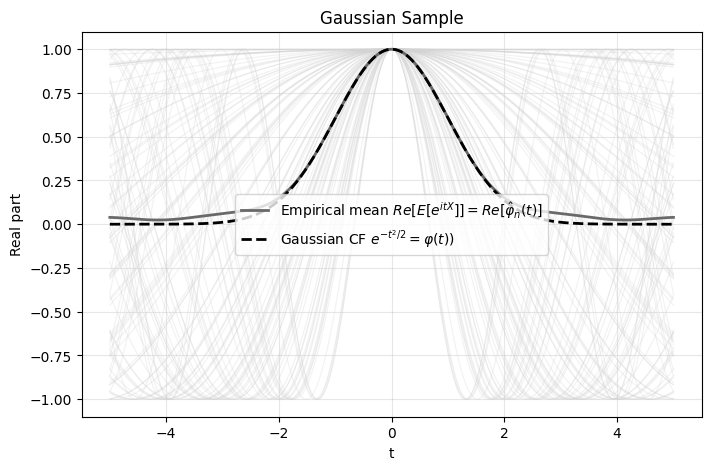

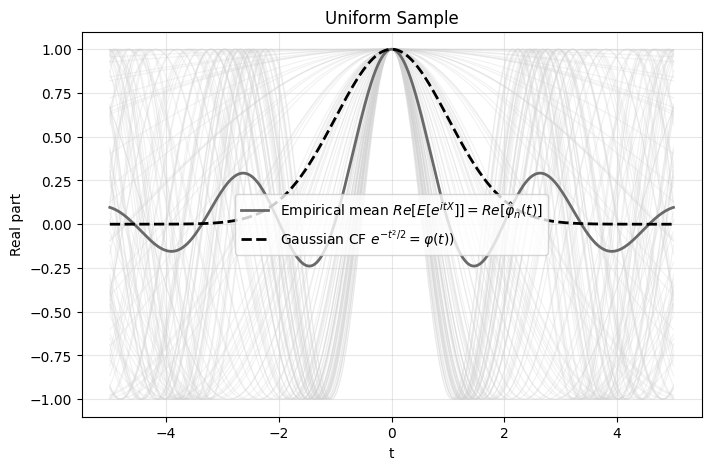

Epps–Pulley Test Results
-------------------------
Gaussian sample: T = 0.064450
Uniform sample:  T = 0.924244

Conclusion: Gaussian sample is closer to the standard normal reference distribution.


In [6]:
def eps_pulley(X, k, plot=False, title=""):
    t = np.linspace(-5, 5, k)

    # theoretical characteristic function of N(0,1)
    phi_gauss = np.exp(-0.5 * t**2)

    # empirical characteristic function
    X_t = np.outer(X, t)
    exp_itx = np.exp(1j * X_t)   # switched to +1j
    phi_emp = np.mean(exp_itx, axis=0)

    # integrated squared error
    err = np.abs(phi_emp - phi_gauss)**2
    T = np.trapezoid(err, t)

    if plot:
        plt.figure(figsize=(8, 5))

        # plot individual exp(itx) curves (real parts)
        for i in range(len(X)):
            plt.plot(
                t,
                exp_itx[i].real,
                color="lightgrey",
                alpha=0.3,
                linewidth=0.8
            )

        # empirical mean
        plt.plot(
            t,
            phi_emp.real,
            color="dimgray",
            linewidth=2,
            label=r"Empirical mean $Re[E[e^{itX}]]=Re[\hat\varphi_n(t)]$"
        )

        # theoretical Gaussian CF
        plt.plot(
            t,
            phi_gauss,
            color="black",
            linestyle="--",
            linewidth=2,
            label=r"Gaussian CF $e^{-t^2/2}=\varphi(t))$"
        )

        plt.xlabel("t")
        plt.ylabel("Real part")
        plt.title(title)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    return T


k = 1000

T_gaussian = eps_pulley(
    X_gaussian, k,
    plot=True,
    title="Gaussian Sample"
)

T_uniform = eps_pulley(
    X_uniform, k,
    plot=True,
    title="Uniform Sample"
)

print("Epps–Pulley Test Results")
print("-------------------------")
print(f"Gaussian sample: T = {T_gaussian:.6f}")
print(f"Uniform sample:  T = {T_uniform:.6f}")

if T_gaussian < T_uniform:
    print("\nConclusion: Gaussian sample is closer to the standard normal reference distribution.")
else:
    print("\nConclusion: Uniform sample appears closer to the standard normal reference distribution.")

The lower T statistic for the gaussian sample indicates less "gap". I haven't looked into the limiting distribution of the Epps-Pulley Test Statistic that would be used to calculate p-values.

We can also test the robustness to the number of divisions in the trapezoidal Riemann sum and see it converges quite quickly.

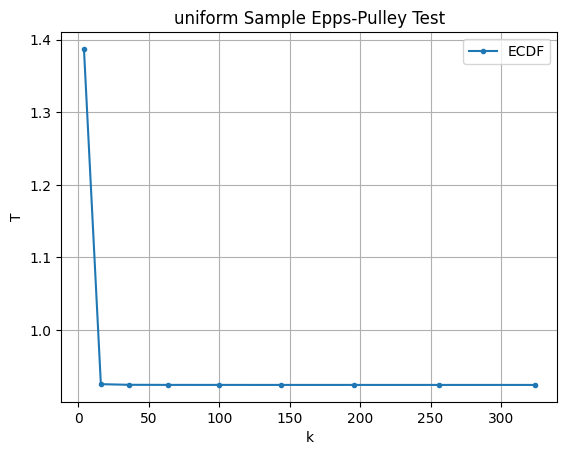

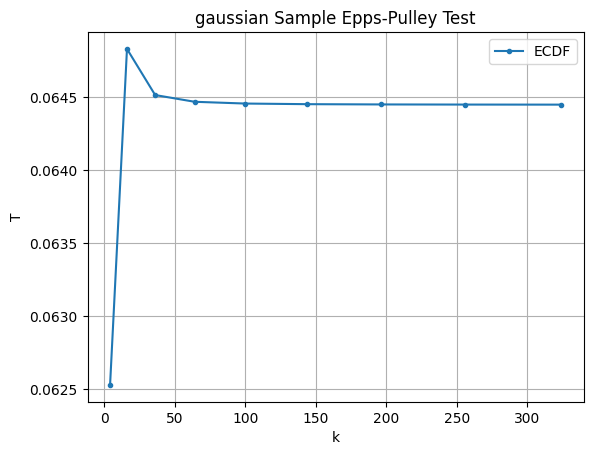

In [7]:
ks = [x**2 for x in range(2,20,2)]
T_gaussian = [eps_pulley(X_gaussian, k) for k in ks]
T_uniform = [eps_pulley(X_uniform, k) for k in ks]

plots = [
    ("uniform Sample", T_uniform),
    ("gaussian Sample", T_gaussian)
]

for i, (title, T) in enumerate(plots, start=1):
    plt.plot(ks, T, marker='.', label='ECDF')
    plt.title(f'{title} Epps-Pulley Test')
    plt.xlabel('k')
    plt.ylabel('T')
    plt.legend()
    plt.grid(True)
    plt.show()

## Gradient Descent

Now we know how to quantify the gap between data and a target distribution with Epps-Pulley. Lets make a neural network output data that fits the desired target distribution. First lets send 1D data through a random, untrained neural network and check its output distribution.

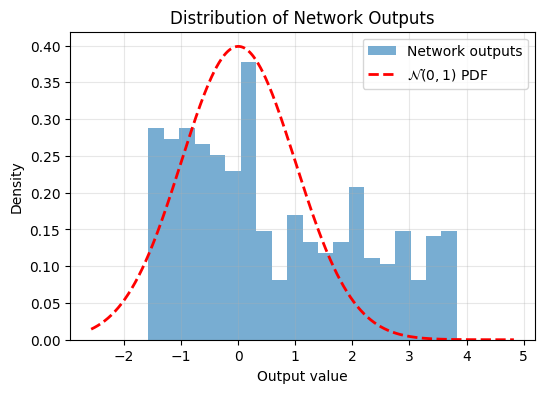

In [8]:
def plot_output_distribution(model, X, bins=20):
    """
    Plot model output histogram against standard normal PDF.
    
    Args:
        model: PyTorch model
        X: input tensor
        bins: histogram bins
    """
    model.eval()

    with torch.no_grad():
        Y = model(X).squeeze().cpu().numpy()

    plt.figure(figsize=(6,4))

    plt.hist(
        Y,
        bins=bins,
        density=True,
        alpha=0.6,
        label="Network outputs"
    )

    x = np.linspace(Y.min() - 1, Y.max() + 1, 500)

    plt.plot(
        x,
        stats.norm.pdf(x, loc=0, scale=1),
        'r--',
        linewidth=2,
        label=r'$\mathcal{N}(0,1)$ PDF'
    )

    plt.xlabel("Output value")
    plt.ylabel("Density")
    plt.title("Distribution of Network Outputs")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# -----------------------
# Example setup
# -----------------------
n = 1000
hidden = 16

X = torch.rand(n) * 20 - 10
X = X.unsqueeze(1)

X_train = X[:n//2]
X_test = X[n//2:]

model = torch.nn.Sequential(
    torch.nn.Linear(1, hidden),
    torch.nn.ReLU(),
    torch.nn.Linear(hidden, 1)
)

# Before training
plot_output_distribution(model, X_test)

We can see the output isn't very Gaussian. Now lets train the model using the Epps-Pulley Regularizer,

Epoch 200/2000, Loss: 0.0006097470759414136
Epoch 400/2000, Loss: 0.0005753693985752761
Epoch 600/2000, Loss: 0.0005708417156711221
Epoch 800/2000, Loss: 0.0005661727045662701
Epoch 1000/2000, Loss: 0.0005581520381383598
Epoch 1200/2000, Loss: 0.0005494060460478067
Epoch 1400/2000, Loss: 0.0005422477843239903
Epoch 1600/2000, Loss: 0.0005335460300557315
Epoch 1800/2000, Loss: 0.0005124190938659012
Epoch 2000/2000, Loss: 0.0004806756041944027


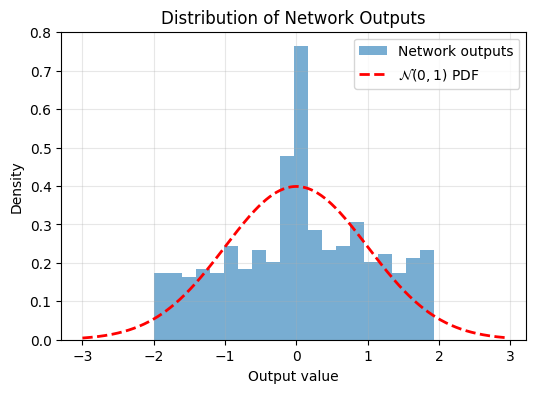

In [9]:
def epps_pulley_1d(X, k):
    t = torch.linspace(-5, 5, k, device=X.device)

    # theoretical CF of N(0,1)
    phi_gaussian = torch.exp(-0.5 * t**2)

    # empirical CF
    X_t = X.unsqueeze(1) * t
    phi_emp = torch.mean(torch.exp(-1j * X_t), dim=0)

    # weighted squared error
    err = phi_gaussian * torch.abs(phi_emp - phi_gaussian)**2

    T = torch.trapz(err, t)

    return T

epochs = 2000

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = lambda x: epps_pulley_1d(x, k=17)

for epoch in range(epochs):
    optimizer.zero_grad()
    loss = loss_fn(model(X_train))
    loss.backward()
    optimizer.step()
    if (epoch+1) % (epochs//10) == 0:
      print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")

plot_output_distribution(model, X_test)

Now we can see the trained model's output is more Gaussian.

# Multiple Dimensions
## Multidimensional Gaussian Regularization

It's not immediately clear how to apply this in higher dimensions without running into the curse of dimensionality. Naively approximating the integral in higher dimensions would require evaluating it at a number of points that scales exponentially with dimension. In the 1D example we used $17$ points. We want to avoid 2D requiring $17^2$ points, 3D requiring $17^3$, and so on.

The paper's idea is instead to sample directions in the $n$-dimensional space, project the $n$-dimensional points onto these directions, and then compute the corresponding univariate test statistics.

For a multivariate Gaussian random variable

$$
X \sim \mathcal{N}(0, I)
$$

any linear projection $u^T X$ is also Gaussian. And when $u$ is a unit vector $\|u\|=1$, the variance remains unchanged:

$$
\text{Var}(u^T X)=u^T I u = 1
$$

This means every projection of a standard isotropic Gaussian looks like:

$$
u^T X \sim \mathcal{N}(0,1)
$$

The converse is what makes this useful: by the Cramér–Wold theorem, if **every** one-dimensional projection of a distribution is standard Gaussian, then the full multivariate distribution must itself be a standard(isotropic) multivariate Gaussian.

This gives us a scalable approximation strategy: instead of testing Gaussianity over the full $n$-dimensional space, we test many random one-dimensional projections.

That’s the core idea behind SIGReg: approximate high-dimensional Gaussian regularization using randomized projections rather than exponentially expensive multidimensional integration.

Here I’ll demonstrate this in two dimensions. First, we’ll inspect scatter plots of 2D data, then choose a random direction on the 2D unit circle, project the points onto that direction, and examine the resulting histograms. The key observation is that these projections reduce the problem back to one dimension, where we can run the same Epps–Pulley test as before.

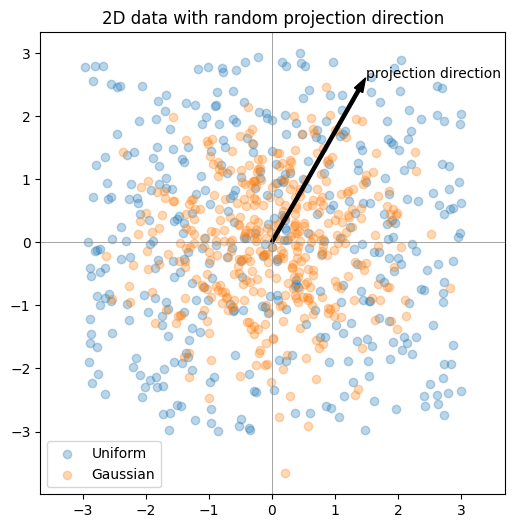

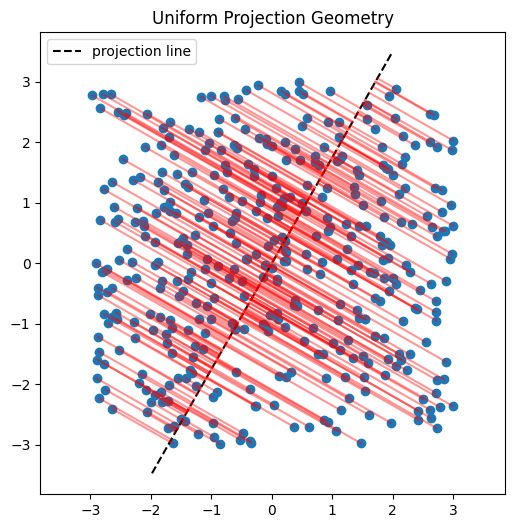

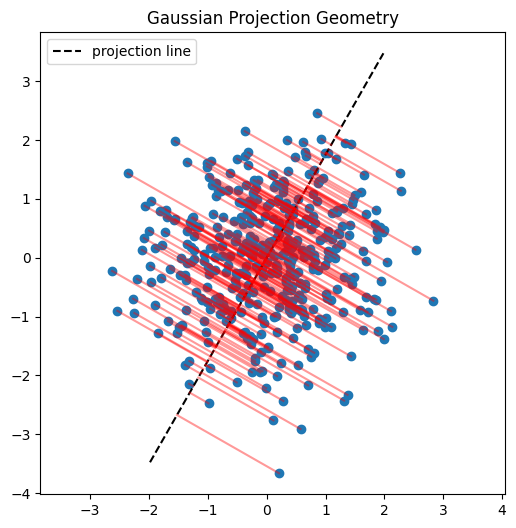

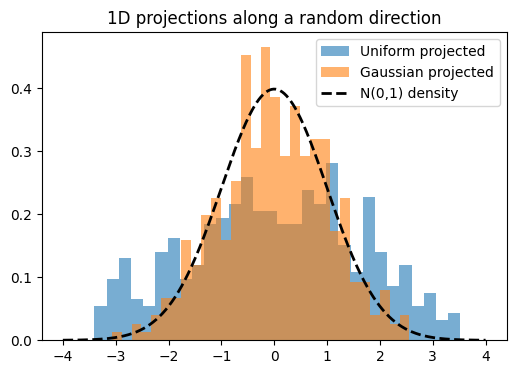

In [10]:
n = 400

# Generate samples
X_uniform_2d = np.random.rand(n, 2) * 6 - 3
X_gaussian_2d = np.random.randn(n, 2)

# Random unit direction
v = np.random.randn(2)
v = v / np.linalg.norm(v)

# Projections
proj_uniform = X_uniform_2d @ v
proj_gaussian = X_gaussian_2d @ v


# ----------------------------
# 1. Scatter plot with direction
# ----------------------------
plt.figure(figsize=(6,6))

plt.scatter(
    X_uniform_2d[:,0],
    X_uniform_2d[:,1],
    alpha=0.3,
    label="Uniform"
)

plt.scatter(
    X_gaussian_2d[:,0],
    X_gaussian_2d[:,1],
    alpha=0.3,
    label="Gaussian"
)

plt.arrow(
    0, 0,
    3*v[0], 3*v[1],
    width=0.05,
    color="black",
    length_includes_head=True
)

plt.text(
    3*v[0],
    3*v[1],
    "projection direction",
    fontsize=10
)

plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.legend()
plt.title("2D data with random projection direction")
plt.axis("equal")
plt.show()


# ----------------------------
# 2. Projection geometry comparison
# ----------------------------

datasets = [
    ("Uniform Projection Geometry", X_uniform_2d),
    ("Gaussian Projection Geometry", X_gaussian_2d)
]

for title, X_subset in datasets:
    plt.figure(figsize=(6,6))
    plt.scatter(X_subset[:,0], X_subset[:,1])

    # projection line
    t_line = np.linspace(-4, 4, 100)
    plt.plot(
        t_line*v[0],
        t_line*v[1],
        'k--',
        label='projection line'
    )

    # projection segments
    for x in X_subset:
        proj = (x @ v) * v
        plt.plot(
            [x[0], proj[0]],
            [x[1], proj[1]],
            'r-',
            alpha=0.4
        )

    plt.legend()
    plt.title(title)
    plt.axis("equal")
    plt.show()


# ----------------------------
# 3. Histogram comparison
# ----------------------------
x = np.linspace(-4, 4, 400)

plt.figure(figsize=(6,4))

plt.hist(
    proj_uniform,
    bins=30,
    density=True,
    alpha=0.6,
    label="Uniform projected"
)

plt.hist(
    proj_gaussian,
    bins=30,
    density=True,
    alpha=0.6,
    label="Gaussian projected"
)

plt.plot(
    x,
    stats.norm.pdf(x),
    'k--',
    lw=2,
    label='N(0,1) density'
)

plt.legend()
plt.title("1D projections along a random direction")
plt.show()

## SIGReg

SIGReg functions the same as above except takes the mean of $k$ slices. See the code block below which is similar to the code in the paper.



In [11]:
def SIGReg(x, num_slices=256, k=17):
    # x: (N, D) samples
    N, D = x.shape
    device = x.device

    # --- Projection directions ---
    A = torch.randn(D, num_slices, device=device)
    A /= A.norm(dim=0)  # normalize columns → unit directions

    # Project to 1D: shape → (N, num_slices)
    X_proj = x @ A

    # --- Integration points ---
    t = torch.linspace(-5, 5, k, device=device)  # (k,)
    phi_normal = torch.exp(-0.5 * t**2)          # (k,)
    weight = phi_normal                          # Gaussian window

    # Broadcast shapes: (N, M, 1) ⋅ (1, 1, k)
    X_t = X_proj.unsqueeze(-1) * t

    # Empirical characteristic function across samples
    ecf = torch.exp(-1j * X_t).mean(dim=0)  # (M, k)

    # Squared difference
    diff_sq = (ecf - phi_normal).abs()**2  # (M, k)

    # Weighted integration for all projections → shape (M,)
    per_direction_T = torch.trapz(diff_sq * weight, t, dim=1) * N

    # GLOBAL aggregation — MEAN instead of MAX
    T_global = per_direction_T.mean()

    return T_global

Now lets make a network's 10-dimensional output standard gaussian. We'll plot a histogram in the direction of the first dimension, before and after training on the regularizer.

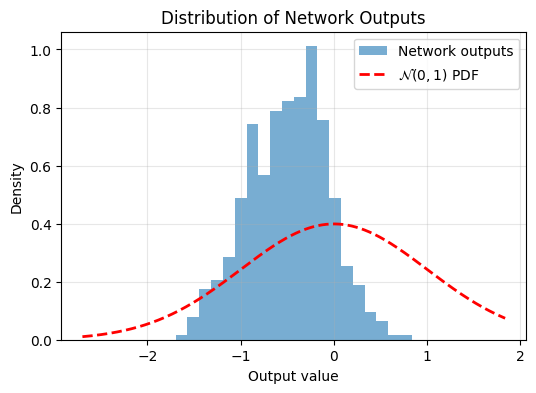

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n = 1000
hidden = 20
D = 10
X = torch.rand((n,D))*10-5   # uniform(0,6)

X_train = X[:n//2].to(device)
X_test = X[n//2:].to(device)

model = torch.nn.Sequential(
    torch.nn.Linear(D, hidden),
    torch.nn.ReLU(),
    torch.nn.Linear(hidden, D)
).to(device)

Y = model(X_test)

def plot_output_distribution(model, X, bins=20):
    """
    Plot model output histogram against standard normal PDF.
    
    Args:
        model: PyTorch model
        X: input tensor
        bins: histogram bins
    """
    model.eval()

    with torch.no_grad():
        Y = model(X).squeeze().cpu().numpy()[:,0]

    plt.figure(figsize=(6,4))

    plt.hist(
        Y,
        bins=bins,
        density=True,
        alpha=0.6,
        label="Network outputs"
    )

    x = np.linspace(Y.min() - 1, Y.max() + 1, 500)

    plt.plot(
        x,
        stats.norm.pdf(x, loc=0, scale=1),
        'r--',
        linewidth=2,
        label=r'$\mathcal{N}(0,1)$ PDF'
    )

    plt.xlabel("Output value")
    plt.ylabel("Density")
    plt.title("Distribution of Network Outputs")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


plot_output_distribution(model, X_test)

Again, not very Gaussian. Lets train using SIGReg:

Epoch 100/1000, Loss: 2.2469592094421387
Epoch 200/1000, Loss: 0.9632902145385742
Epoch 300/1000, Loss: 0.7503044605255127
Epoch 400/1000, Loss: 0.548032283782959
Epoch 500/1000, Loss: 0.42803165316581726
Epoch 600/1000, Loss: 0.4888719618320465
Epoch 700/1000, Loss: 0.4376848340034485
Epoch 800/1000, Loss: 0.37319087982177734
Epoch 900/1000, Loss: 0.3438933491706848
Epoch 1000/1000, Loss: 0.2580392360687256


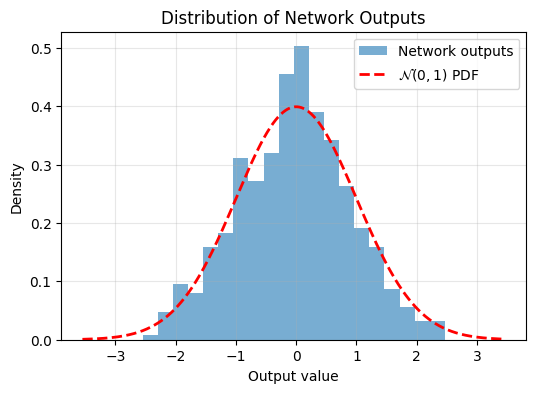

In [13]:
epochs = 1000

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = lambda x: SIGReg(x)

for epoch in range(epochs):
    optimizer.zero_grad()
    loss = loss_fn(model(X_train))
    loss.backward()
    optimizer.step()
    if (epoch+1) % (epochs//10) == 0:
      print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")

Y=model(X_test)
plot_output_distribution(model, X_test)

And now after training, the output is more Gaussian. So adding this regularizer to your objective function encourages Gaussian latent embeddings.

In a future blog post, I'd like to train a small JEPA model using SIGReg as in "LeWorldModel: Stable End-to-End Joint-Embedding Predictive Architecture from Pixels"[@maes2026].